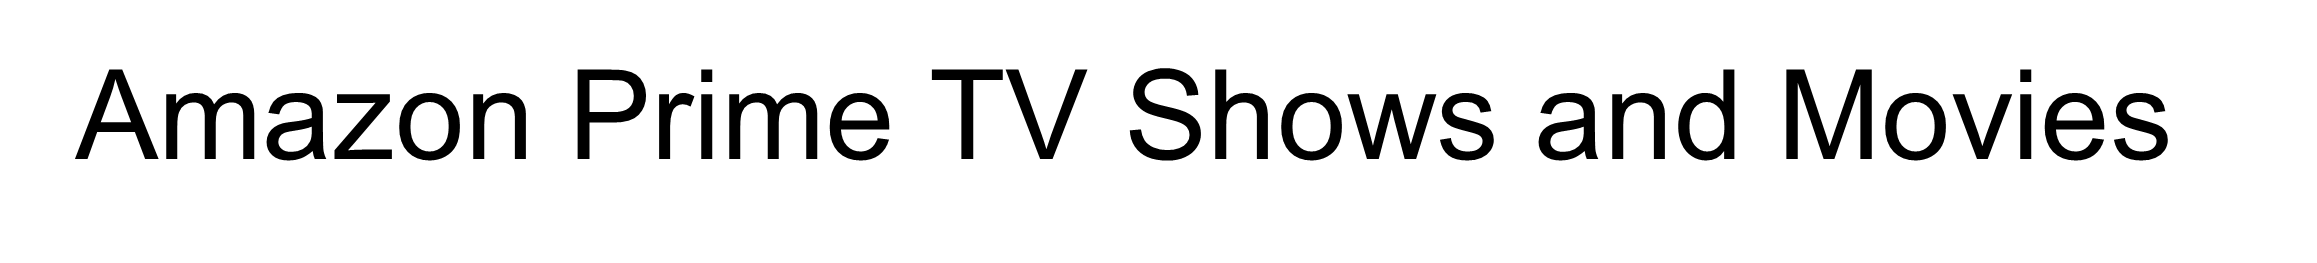

# Project Description

[link text](https://)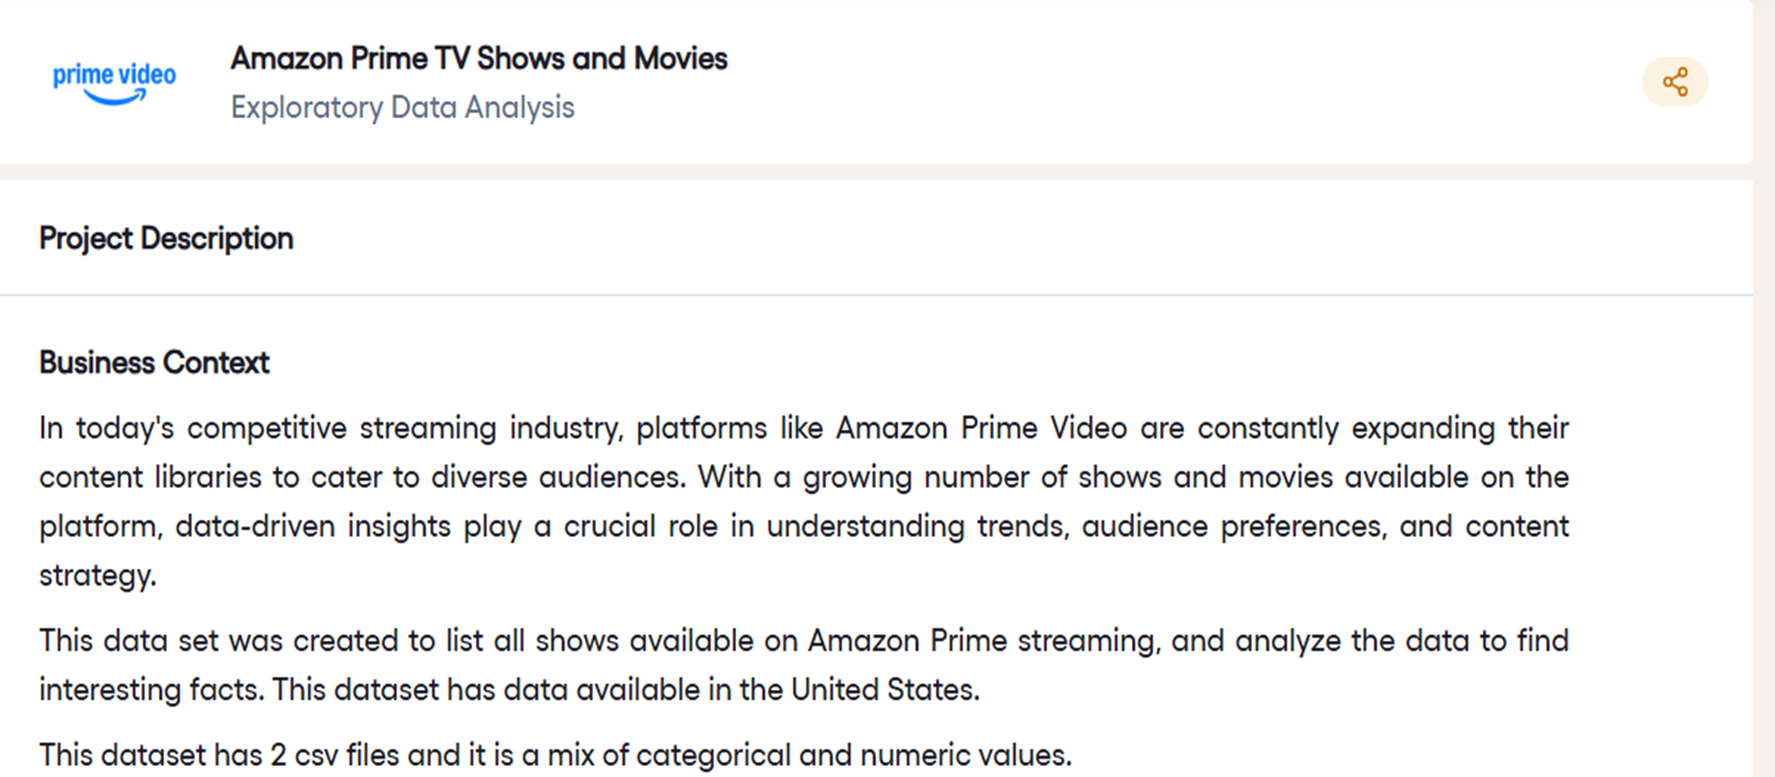

**Objectives:**

* Analyze Amazon Prime content dataset

* Identify streaming content trends

* Perform data visualization

* Build machine learning prediction models

* Compare algorithm performance

**Project Goals:**

* Analyze streaming platform content

* Perform Exploratory Data Analysis

* Identify patterns in content

* Build prediction models using machine learning algorithms

# Import Required Libraries



This step imports all necessary Python libraries required for data handling, visualization, and machine learning. These libraries help perform analysis, plotting graphs, and building prediction models.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


# Load Dataset

**The dataset is loaded into Python using pandas. Two datasets are used:**

* Titles dataset containing content details
* Credits dataset containing actor and crew details

In [4]:
titles = pd.read_csv("titles.csv.zip")
credits = pd.read_csv("credits.csv.zip")

titles.head()
credits.head()


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


# Dataset Overview

* This step helps understand dataset structure including number of rows, columns, and data types. It helps identify data quality and structure.
* Checks for missing or null values in dataset. Missing values affect model performance and must be handled properly.

In [5]:
# Shape of Dataset
print("Titles Shape:", titles.shape)
print("Credits Shape:", credits.shape)

# Column Information
titles.info()
credits.info()

# Checking Missing Values
titles.isnull().sum()
credits.isnull().sum()


Titles Shape: (9871, 15)
Credits Shape: (124235, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score          

,0
person_id,0
id,0
name,0
character,16287
role,0


# Remove Duplicate Records

Duplicate records create incorrect analysis results. Removing duplicates ensures dataset accuracy.

In [6]:
titles.drop_duplicates(inplace=True)
credits.drop_duplicates(inplace=True)


# Handle Missing Values

Missing values are replaced using:

* "Unknown" for categorical data

* Median value for numeric data

* This improves data consistency.

In [7]:
titles['age_certification'].fillna("Unknown", inplace=True)
titles['genres'].fillna("Unknown", inplace=True)
titles['production_countries'].fillna("Unknown", inplace=True)

titles['runtime'].fillna(titles['runtime'].median(), inplace=True)
titles['imdb_score'].fillna(titles['imdb_score'].median(), inplace=True)
titles['tmdb_score'].fillna(titles['tmdb_score'].median(), inplace=True)


# Merge Dataset

Combines titles and credits dataset using common ID. This creates one complete dataset containing all information.

In [8]:
df = pd.merge(titles, credits, on="id", how="left")
df = df.drop_duplicates(subset=['id'])

df.head()


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Unknown,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
27,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,Unknown,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8,29993.0,Myrna Loy,Milly Stephenson,ACTOR
58,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,Unknown,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4,25018.0,Cary Grant,Walter Burns,ACTOR
94,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,Unknown,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6,14701.0,Humphrey Bogart,Dixon 'Dix' Steele,ACTOR


## EXPLORATORY DATA ANALYSIS
# Movies vs TV Shows Analysis

Analyzes distribution of Movies and TV Shows. Helps understand platform content distribution.

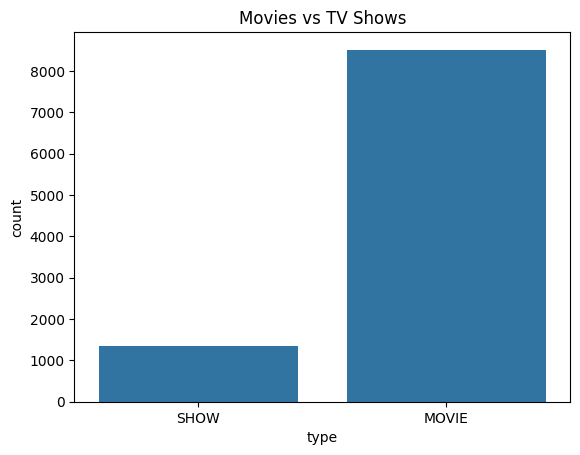

In [9]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()


# Content Release Trend

Shows how content production has increased over years. Helps identify streaming growth trends.

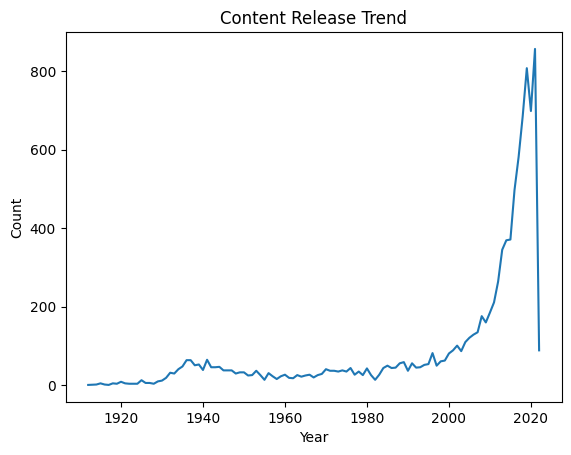

In [10]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


# Genre Analysis

Identifies most popular genres available on platform. Helps understand audience preference.

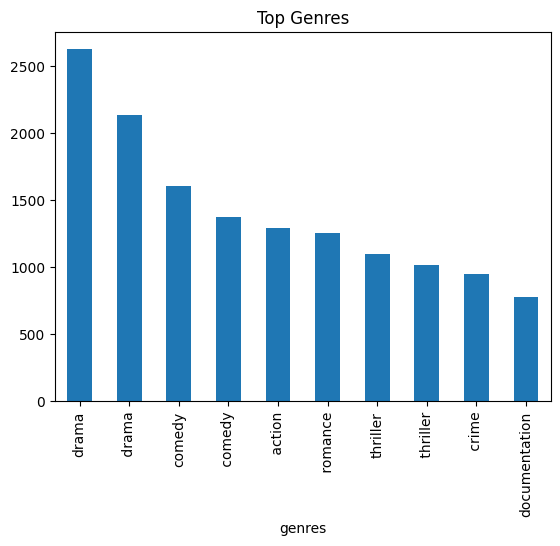

In [11]:
df['genres'] = df['genres'].astype(str)
df['genres'] = df['genres'].str.strip("[]").str.replace("'", "").str.split(",")

genre_df = df.explode('genres')

genre_df['genres'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()


# Ratings Distribution

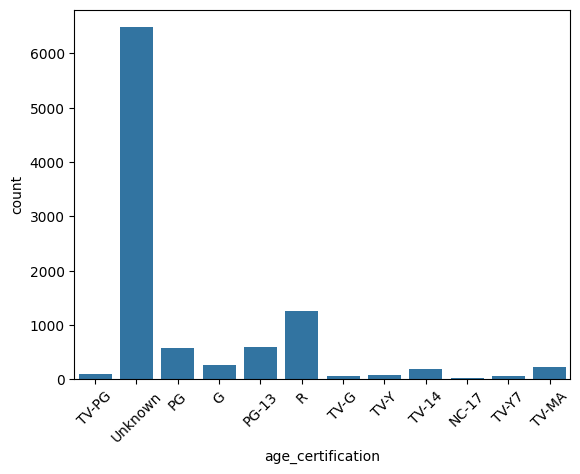

In [12]:
sns.countplot(x='age_certification', data=df)
plt.xticks(rotation=45)
plt.show()


# Country Analysis

Shows which countries produce maximum content. Helps understand global entertainment distribution.

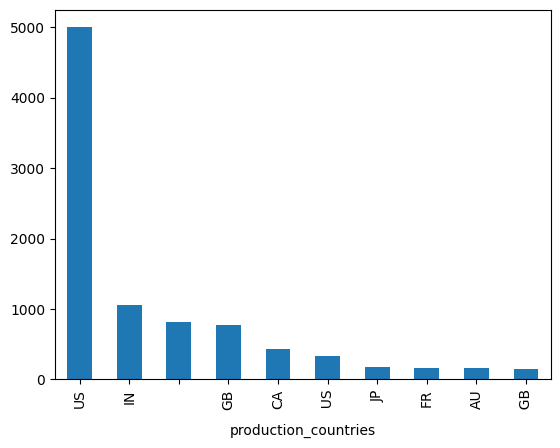

In [16]:
df['production_countries'] = df['production_countries'].astype(str)
df['production_countries'] = df['production_countries'].str.strip("[]").str.replace("'", "").str.split(",")

country_df = df.explode('production_countries')

country_df['production_countries'].value_counts().head(10).plot(kind='bar')
plt.show()


# Runtime Distribution

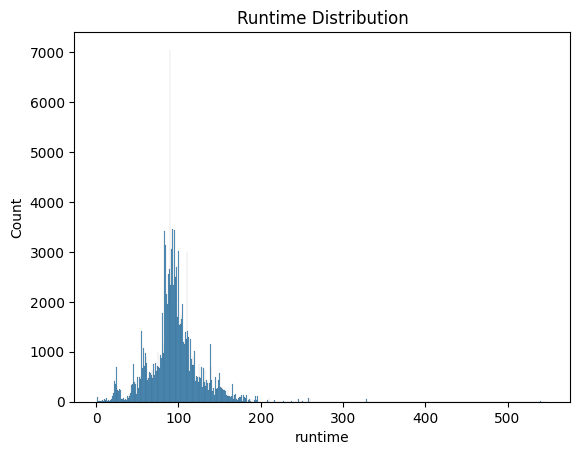

In [16]:
sns.histplot(df['runtime'])
plt.title("Runtime Distribution")
plt.show()


## MACHINE LEARNING SECTION

* Feature Selection
* Data Encoding
* Train Test Split

In [26]:
ml_df = df[['type', 'release_year', 'runtime', 'age_certification']]
ml_df.dropna(inplace=True)


In [27]:
le = LabelEncoder()

ml_df['type'] = le.fit_transform(ml_df['type'])
ml_df['age_certification'] = le.fit_transform(ml_df['age_certification'])


In [28]:
X = ml_df[['release_year', 'runtime', 'age_certification']]
y = ml_df['type']


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Algorithm 1 – Random Forest

Random Forest is an ensemble algorithm that uses multiple decision trees. It provides high accuracy and reduces overfitting.

In [35]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))



Random Forest Accuracy: 0.9680851063829787


# Algorithm 2 – Decision Tree

Decision Tree is a simple classification algorithm. It creates decision rules based on dataset features.

In [38]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.96403242147923


# Model Evaluation

Evaluates model performance using accuracy score, confusion matrix, and classification report.

In [39]:
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1725
           1       0.86      0.90      0.88       249

    accuracy                           0.97      1974
   macro avg       0.92      0.94      0.93      1974
weighted avg       0.97      0.97      0.97      1974

[[1688   37]
 [  26  223]]


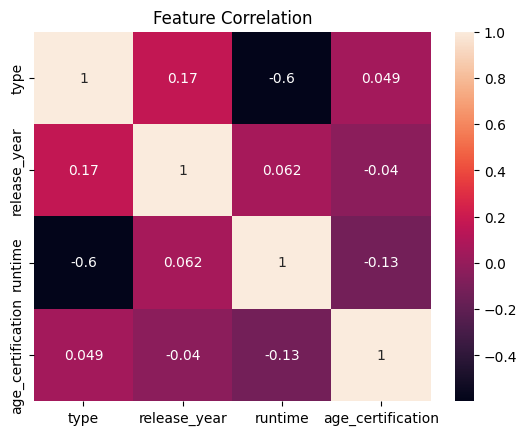

In [34]:
sns.heatmap(ml_df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()


# Conclusion

The project successfully analyzes streaming platform content and builds prediction models.

# Future Implementation

1. Recommendation System

Suggest movies and TV shows based on user preference.

2. Deep Learning Model

Use neural networks for better prediction accuracy.

3. Real-Time Streaming Dashboard

Create interactive dashboard using Streamlit or Power BI.

 4. Sentiment Analysis

Analyze user reviews and feedback to understand audience satisfaction.

5. Content Popularity Prediction

Predict trending content using advanced AI models.